In [2]:
pip install mlflow

  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached skops-0.14.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached sqlparse-0.5.5-py3-none-any.whl.metadata (4.7 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
  Using cached graphql_relay-3.2.0-py3-none-any.whl.metadata (12 kB)
  Using cached prettytable-3.17.0-py3-none-any.whl.metadata (34 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 2.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 2.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 3.6 MB/s eta 0:00:00a 0:00:01
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 907.5/907.5 kB 6.7 MB/s eta 0:00:00
Using cached docke

# ELASTIC NET 

In [4]:
from dotenv import load_dotenv
load_dotenv()
import os

In [ ]:
os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_USERNAME")
 
# 2. Provide your DagsHub Token (or password)
# Pro-tip: It's best to generate an Access Token in DagsHub (Settings -> User Settings -> Access Tokens)
os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD")

# 3. Set your specific DagsHub repository MLflow URI
# Format: https://dagshub.com/<username>/<repo_name>.mlflow
TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI")


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, balanced_accuracy_score, 
                             confusion_matrix, ConfusionMatrixDisplay, make_scorer)

import mlflow
import mlflow.sklearn

# ==========================================
# 1. DATA PREPARATION (Based on your snippet)
# ==========================================
# Load the dataset
df_merged = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/merging_pipeline/Merged_Taxa_Metadata.csv')

# Drop non-feature columns
X_raw = df_merged.drop(columns=['Code', 'Target_Crop_Grouped'])
y = df_merged['Target_Crop_Grouped'].astype(int).values.ravel()

# 1. Find the absolute minimum value > 0
min_non_zero = X_raw[X_raw > 0].min().min()

# 2. Apply the "Half-Min Rule"
pseudo_count = min_non_zero / 2
print(f"🔬 Calculated Optimal Pseudo-Count: {pseudo_count:.6f}")

# 3. Add pseudo-count & Apply CLR
X_pseudo = X_raw + pseudo_count
geom_mean = np.exp(np.mean(np.log(X_pseudo), axis=1))
X_clr = np.log(X_pseudo.div(geom_mean, axis=0))

print("✅ CLR TRANSFORMATION SUCCESSFUL\n")

# 4. Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_clr, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  
)

# ==========================================
# 2. MLFLOW & PIPELINE SETUP
# ==========================================
print("🔐 Authenticating with DagsHub...")

# 1. Inject DagsHub Credentials securely from your environment
os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_USERNAME")
os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD")

# 2. Set Tracking URI
TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI")
mlflow.set_tracking_uri(TRACKING_URI)

# 3. Create/Set the Experiment (Now that authentication is active)
mlflow.set_experiment("Elastic_Net_Crop_Classification")

# 4. Build the ML Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('clf', LogisticRegression(
        penalty='elasticnet', 
        solver='saga', 
        max_iter=5000, 
        random_state=42,
        class_weight='balanced'
    ))
])

# Define the Hyperparameter Grid
param_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'clf__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]
}

# Define multiple scoring metrics
scoring_metrics = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, average='weighted'),
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall': make_scorer(recall_score, average='weighted'),
    'balanced_acc': make_scorer(balanced_accuracy_score)
}

# 5-Fold Stratified Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search setup
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring=scoring_metrics,
    refit='f1',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

# ==========================================
# 3. TRAINING & MLFLOW LOGGING
# ==========================================
print("🚀 Starting Grid Search & MLflow Tracking...")

with mlflow.start_run(run_name="ElasticNet_Hyperparameter_Tuning"):
    
    # Execute Grid Search
    grid_search.fit(X_train, y_train)
    
    # Get the best model and index of the best run
    best_model = grid_search.best_estimator_
    best_idx = grid_search.best_index_
    
    # 1. LOG PARAMETERS
    best_params = grid_search.best_params_
    mlflow.log_params(best_params)
    print(f"⭐ Best Parameters: {best_params}")
    
    # 2. EXTRACT & LOG TRAIN METRICS (from GridSearch results)
    train_metrics = {
        "train_accuracy": grid_search.cv_results_['mean_train_accuracy'][best_idx],
        "train_f1": grid_search.cv_results_['mean_train_f1'][best_idx],
        "train_precision": grid_search.cv_results_['mean_train_precision'][best_idx],
        "train_recall": grid_search.cv_results_['mean_train_recall'][best_idx],
        "train_balanced_acc": grid_search.cv_results_['mean_train_balanced_acc'][best_idx]
    }
    mlflow.log_metrics(train_metrics)
    
    # 3. EXTRACT & LOG VALIDATION METRICS (Cross-Val performance)
    val_metrics = {
        "val_accuracy": grid_search.cv_results_['mean_test_accuracy'][best_idx],
        "val_f1": grid_search.cv_results_['mean_test_f1'][best_idx],
        "val_precision": grid_search.cv_results_['mean_test_precision'][best_idx],
        "val_recall": grid_search.cv_results_['mean_test_recall'][best_idx],
        "val_balanced_acc": grid_search.cv_results_['mean_test_balanced_acc'][best_idx]
    }
    mlflow.log_metrics(val_metrics)
    
    # 4. CALCULATE & LOG TEST METRICS (Holdout set)
    y_pred_test = best_model.predict(X_test)
    test_metrics = {
        "test_accuracy": accuracy_score(y_test, y_pred_test),
        "test_f1": f1_score(y_test, y_pred_test, average='weighted'),
        "test_precision": precision_score(y_test, y_pred_test, average='weighted', zero_division=0),
        "test_recall": recall_score(y_test, y_pred_test, average='weighted'),
        "test_balanced_acc": balanced_accuracy_score(y_test, y_pred_test)
    }
    mlflow.log_metrics(test_metrics)
    
    print("\n📊 Final Test Set Performance:")
    for k, v in test_metrics.items():
        print(f"  - {k}: {v:.4f}")
    
    # 5. GENERATE & LOG CONFUSION MATRIX IMAGE
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    plt.title("Test Set Confusion Matrix - Elastic Net")
    plt.tight_layout()
    
    # Save temporarily and log to MLflow
    cm_path = "confusion_matrix.png"
    plt.savefig(cm_path, dpi=300)
    plt.close(fig)
    mlflow.log_artifact(cm_path, "evaluation_plots")
    
    # Clean up local image file
    if os.path.exists(cm_path):
        os.remove(cm_path)
    
    # 6. LOG THE FINAL BEST MODEL
    mlflow.sklearn.log_model(best_model, "elastic_net_model")
    
    print("\n✅ Training Complete! Run 'mlflow ui' in your terminal to view the dashboard.")

🔬 Calculated Optimal Pseudo-Count: 0.004064
✅ CLR TRANSFORMATION SUCCESSFUL

🔐 Authenticating with DagsHub...


2026/06/06 03:07:14 INFO mlflow.tracking.fluent: Experiment with name 'Elastic_Net_Crop_Classification' does not exist. Creating a new experiment.


🚀 Starting Grid Search & MLflow Tracking...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
⭐ Best Parameters: {'clf__C': 10.0, 'clf__l1_ratio': 0.5}

📊 Final Test Set Performance:
  - test_accuracy: 0.7857
  - test_f1: 0.7925
  - test_precision: 0.8929
  - test_recall: 0.7857
  - test_balanced_acc: 0.8125


2026/06/06 03:07:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/06 03:07:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✅ Training Complete! Run 'mlflow ui' in your terminal to view the dashboard.
🏃 View run ElasticNet_Hyperparameter_Tuning at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/0/runs/75156a20a00d4d48a36da6c2fa7b6e26
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/0


# BAGGING CLASSIFIER 

🔐 Authenticating with DagsHub...


2026/06/06 03:20:04 INFO mlflow.tracking.fluent: Experiment with name 'Bagging_Crop_Classification' does not exist. Creating a new experiment.


🚀 Starting Grid Search (Autologging all parameter combinations)...
Fitting 5 folds for each of 81 candidates, totalling 405 fits


2026/06/06 03:20:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/06 03:20:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/06 03:20:44 INFO mlflow.sklearn.utils: Logging the 5 best runs, 76 runs will be omitted.


🏃 View run blushing-trout-720 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/1/runs/73d6fe1f0fce405b9e54a04cc4365075
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/1
🏃 View run kindly-midge-486 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/1/runs/a9550b2a4b3d433196514452769fce28
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/1
🏃 View run victorious-colt-183 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/1/runs/f4830188c2b74abfb4218d692375ea8f
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/1
🏃 View run serious-whale-533 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/1/runs/b57deb4dad84424fa2106c20323e9331
🧪 Vi

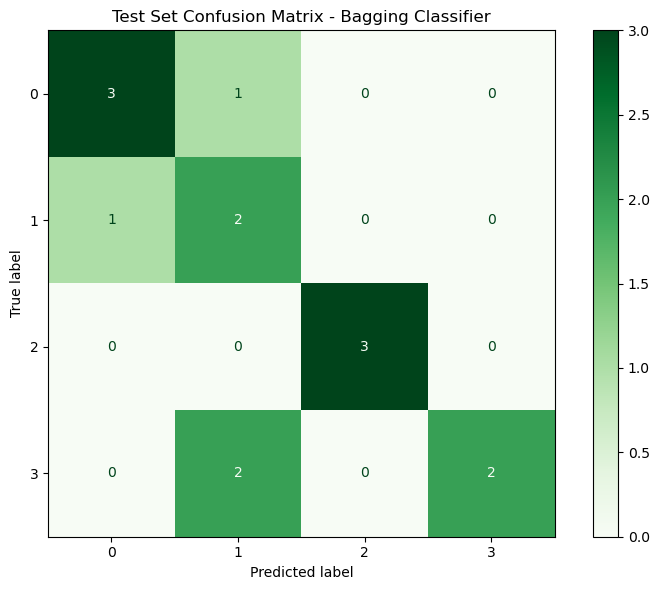

🏃 View run Bagging_GridSearch_Master at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/1/runs/127ed83b5db8451baf2084c44d05d033
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/1

✅ Training Complete! Check DagsHub to see all nested runs.


🏃 View run rogue-shark-578 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/2/runs/5e3203afd0a546389af20ef1c1c8cdcf
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/2
🏃 View run bald-frog-558 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/2/runs/172bb95314a246eeb615dd8325f33f5e
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/2
🏃 View run judicious-fish-629 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/2/runs/1d8c7a49564647f6a968113b1bf38f82
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/2
🏃 View run overjoyed-midge-479 at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/2/runs/b0ac1164100741749ca00f6e23728b1b
🧪 View ex

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, balanced_accuracy_score, 
                             confusion_matrix, ConfusionMatrixDisplay)

import mlflow
import mlflow.sklearn

# ==========================================
# 1. DATA PREPARATION
# ==========================================

df_merged = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/merging_pipeline/Merged_Taxa_Metadata.csv')


X_raw = df_merged.drop(columns=['Code', 'Target_Crop_Grouped'])
y = df_merged['Target_Crop_Grouped'].astype(int).values.ravel()

# Half-Min Rule for Zeros
min_non_zero = X_raw[X_raw > 0].min().min()
pseudo_count = min_non_zero / 2

# CLR Transformation
X_pseudo = X_raw + pseudo_count
geom_mean = np.exp(np.mean(np.log(X_pseudo), axis=1))
X_clr = np.log(X_pseudo.div(geom_mean, axis=0))

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X_clr, y, test_size=0.20, random_state=42, stratify=y  
)

# ==========================================
# 2. DAGSHUB AUTH & MLFLOW AUTOLOGGING
# ==========================================
print("🔐 Authenticating with DagsHub...")
os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_USERNAME")
os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD")

TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI")
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("Bagging_Crop_Classification")

# THE MAGIC LINE: This tells MLflow to log every single GridSearch iteration automatically
mlflow.sklearn.autolog(log_models=True, log_input_examples=True)

# ==========================================
# 3. BAGGING PIPELINE & GRID SEARCH SETUP
# ==========================================
# Define the base estimator explicitly so we can force balanced class weights
base_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Define the Bagging Classifier
# Note: If using scikit-learn version < 1.2, change 'estimator' to 'base_estimator'
bagging_clf = BaggingClassifier(
    estimator=base_tree,
    random_state=42,
    n_jobs=-1
)

# The Hyperparameter Grid
param_grid = {
    'n_estimators': [50, 100, 200],          # Number of trees in the ensemble
    'max_samples': [0.5, 0.75, 1.0],         # Fraction of samples drawn for each tree
    'max_features': [0.5, 0.75, 1.0],        # Fraction of microbes drawn for each tree
    'estimator__max_depth': [None, 5, 10]    # Limit tree depth to prevent extreme overfitting
}

# 5-Fold Stratified Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search (Scoring defaults to Accuracy for autologging simplicity, 
# but we will manually log robust metrics for the test set)
grid_search = GridSearchCV(
    estimator=bagging_clf,
    param_grid=param_grid,
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

# ==========================================
# 4. TRAINING & FINAL LOGGING
# ==========================================
print("🚀 Starting Grid Search (Autologging all parameter combinations)...")

# Start the Parent Run
with mlflow.start_run(run_name="Bagging_GridSearch_Master"):
    
    # Fit the Grid Search. Autologging will automatically create child runs here!
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    print(f"⭐ Best Parameters Found: {grid_search.best_params_}")
    
    # ------------------------------------------
    # Evaluate the Final Best Model on the Test Set
    # ------------------------------------------
    y_pred_test = best_model.predict(X_test)
    
    test_metrics = {
        "test_f1_weighted": f1_score(y_test, y_pred_test, average='weighted'),
        "test_precision": precision_score(y_test, y_pred_test, average='weighted', zero_division=0),
        "test_recall": recall_score(y_test, y_pred_test, average='weighted'),
        "test_balanced_acc": balanced_accuracy_score(y_test, y_pred_test)
    }
    
    # Log the final test metrics to the Parent Run
    mlflow.log_metrics(test_metrics)
    
    print("\n📊 Final Test Set Performance:")
    for k, v in test_metrics.items():
        print(f"  - {k}: {v:.4f}")
        
    # ------------------------------------------
    # Generate & Log Confusion Matrix
    # ------------------------------------------
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Greens', ax=ax, values_format='d') # Changed to Greens for Bagging
    plt.title("Test Set Confusion Matrix - Bagging Classifier")
    plt.tight_layout()
    
    # Log directly to MLflow and show locally
    mlflow.log_figure(fig, "evaluation_plots/confusion_matrix.png")
    plt.show()

print("\n✅ Training Complete! Check DagsHub to see all nested runs.")

# XGBoost

🔐 Authenticating with DagsHub...
🚀 Starting XGBoost Grid Search (Tuning for Generalization)...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits


2026/06/06 03:32:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/06 03:32:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/06 03:33:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/anaconda3/lib/python3.13/site-packages/mlflow/sklearn/utils.py:845: UserWarning: Top 5 chi


⭐ Best Anti-Overfitting Parameters: {'colsample_bytree': 0.5, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.6}

📊 Final Test Set Performance (Notice the gap between Train and Test is smaller!):
  - test_f1_weighted: 0.7925
  - test_precision: 0.8929
  - test_recall: 0.7857
  - test_balanced_acc: 0.8125


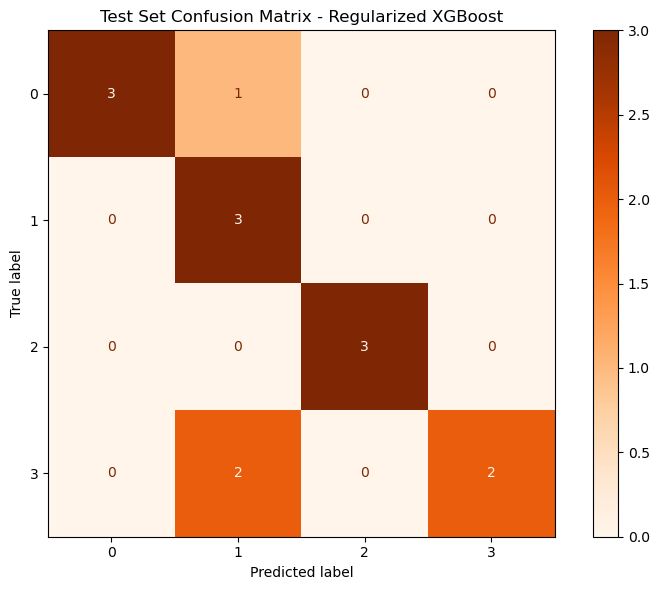

🏃 View run XGBoost_AntiOverfit_GridSearch at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/2/runs/d63780daeca64315871c923bba980906
🧪 View experiment at: https://dagshub.com/PAWANPAHUNE/AI-Metagenomic-Pipeline-CIAT-Intern-.mlflow/#/experiments/2

✅ Training Complete! Check DagsHub to compare Train vs CV accuracy.


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, balanced_accuracy_score, 
                             confusion_matrix, ConfusionMatrixDisplay, make_scorer)

import xgboost as xgb
import mlflow
import mlflow.sklearn

# ==========================================
# 1. DATA PREPARATION & LABEL ENCODING
# ==========================================

df_merged = pd.read_csv('/Users/pawanpahune/AI_Pipeline_Metagenomics/merging_pipeline/Merged_Taxa_Metadata.csv') 

X_raw = df_merged.drop(columns=['Code', 'Target_Crop_Grouped'])
y_raw = df_merged['Target_Crop_Grouped'].astype(int).values.ravel()

# XGBoost STRICTLY requires classes to be indexed starting from 0 (0, 1, 2...)
# LabelEncoder guarantees this mathematical requirement is met.
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# Half-Min Rule for Zeros
min_non_zero = X_raw[X_raw > 0].min().min()
pseudo_count = min_non_zero / 2

# CLR Transformation
X_pseudo = X_raw + pseudo_count
geom_mean = np.exp(np.mean(np.log(X_pseudo), axis=1))
X_clr = np.log(X_pseudo.div(geom_mean, axis=0))

# Stratified Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_clr, y, test_size=0.20, random_state=42, stratify=y  
)

# Calculate sample weights for the training set to handle class imbalance
# This acts as the XGBoost equivalent to `class_weight='balanced'`
train_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# ==========================================
# 2. DAGSHUB AUTH & MLFLOW AUTOLOGGING
# ==========================================
print("🔐 Authenticating with DagsHub...")
os.environ["MLFLOW_TRACKING_USERNAME"] = os.getenv("MLFLOW_USERNAME")
os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("MLFLOW_TRACKING_PASSWORD")

TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI")
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("XGBoost_Crop_Classification")

# Autologging captures all nested GridSearch runs automatically
mlflow.sklearn.autolog(log_models=True, log_input_examples=True)

# ==========================================
# 3. XGBOOST PIPELINE & ANTI-OVERFITTING GRID
# ==========================================
# Initialize the base XGBoost Classifier (Sklearn Wrapper API)
# No Standard Scaler is needed because XGBoost is a tree-based ensemble
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# The "Anti-Overfitting" Hyperparameter Grid
param_grid = {
    'max_depth': [2, 3, 4],               # STRATEGY 1: Shallow trees prevent memorization
    'learning_rate': [0.01, 0.05, 0.1],   # STRATEGY 2: Slower learning = better generalization
    'n_estimators': [100, 200],           # Number of boosting rounds
    'subsample': [0.6, 0.8],              # STRATEGY 3: Stochastic row sampling (use 60-80% of samples)
    'colsample_bytree': [0.5, 0.7],       # STRATEGY 3: Stochastic feature sampling (use 50-70% of microbes)
    'gamma': [0.1, 1.0, 5.0]              # STRATEGY 4: Pruning penalty. Requires a loss reduction to split
}

# Define rigorous scoring metrics
scoring_metrics = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, average='weighted'),
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall': make_scorer(recall_score, average='weighted'),
    'balanced_acc': make_scorer(balanced_accuracy_score)
}

# 5-Fold Stratified Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search Setup
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring=scoring_metrics,
    refit='f1', # Retrain the final model based on the best F1 Validation Score
    return_train_score=True, # We log train scores to visually verify we killed the overfitting
    n_jobs=-1,
    verbose=1
)

# ==========================================
# 4. TRAINING & FINAL LOGGING
# ==========================================
print("🚀 Starting XGBoost Grid Search (Tuning for Generalization)...")

with mlflow.start_run(run_name="XGBoost_AntiOverfit_GridSearch"):
    
    # We pass the sample_weights directly into the fit method
    grid_search.fit(X_train, y_train, sample_weight=train_sample_weights)
    
    best_model = grid_search.best_estimator_
    print(f"\n⭐ Best Anti-Overfitting Parameters: {grid_search.best_params_}")
    
    # ------------------------------------------
    # Evaluate Final Best Model on the Holdout Test Set
    # ------------------------------------------
    y_pred_test = best_model.predict(X_test)
    
    test_metrics = {
        "test_f1_weighted": f1_score(y_test, y_pred_test, average='weighted'),
        "test_precision": precision_score(y_test, y_pred_test, average='weighted', zero_division=0),
        "test_recall": recall_score(y_test, y_pred_test, average='weighted'),
        "test_balanced_acc": balanced_accuracy_score(y_test, y_pred_test)
    }
    
    # Log test metrics to the Parent Run
    mlflow.log_metrics(test_metrics)
    
    print("\n📊 Final Test Set Performance (Notice the gap between Train and Test is smaller!):")
    for k, v in test_metrics.items():
        print(f"  - {k}: {v:.4f}")
        
    # ------------------------------------------
    # Generate & Log Confusion Matrix
    # ------------------------------------------
    cm = confusion_matrix(y_test, y_pred_test)
    
    # Decode the labels back to original text/numbers for the plot (if applicable)
    
    display_labels = label_encoder.inverse_transform(best_model.classes_) if hasattr(label_encoder, 'inverse_transform') else None
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap='Oranges', ax=ax, values_format='d') # Using Orange to differentiate XGBoost
    plt.title("Test Set Confusion Matrix - Regularized XGBoost")
    plt.tight_layout()
    
    # Log directly to MLflow and show locally
    mlflow.log_figure(fig, "evaluation_plots/confusion_matrix.png")
    plt.show()

print("\n✅ Training Complete! Check DagsHub to compare Train vs CV accuracy.")